# Classification Project: Online Shoppers Purchasing Intention
**Objective:** Predict the purchasing intention (Revenue) of e-commerce users based on their navigation data (clickstream and session details).

## Notebook 1: Exploratory Data Analysis (EDA) and Statistical Evaluation

The goal of this first notebook is to thoroughly analyze the dataset to understand its underlying structure and critical issues, **without applying any transformations that could cause Data Leakage**. To ensure a robust methodology, the actual data preprocessing (Scaling, Outlier Removal, and SMOTE) will be executed exclusively within the Cross-Validation pipelines in the next phase.

In this exploratory phase, we will focus on:
1. **Class Imbalance Analysis:** Identifying the "Accuracy Paradox" risk.
2. **Statistical Feature Evaluation:** Using Chi-Square Test and Mutual Information.
3. **Outlier Profiling:** Detecting multivariate anomalies using the Local Outlier Factor (LOF).

--- DATASET LOADING ---
Dataset Dimensions: 12330 rows, 18 columns.



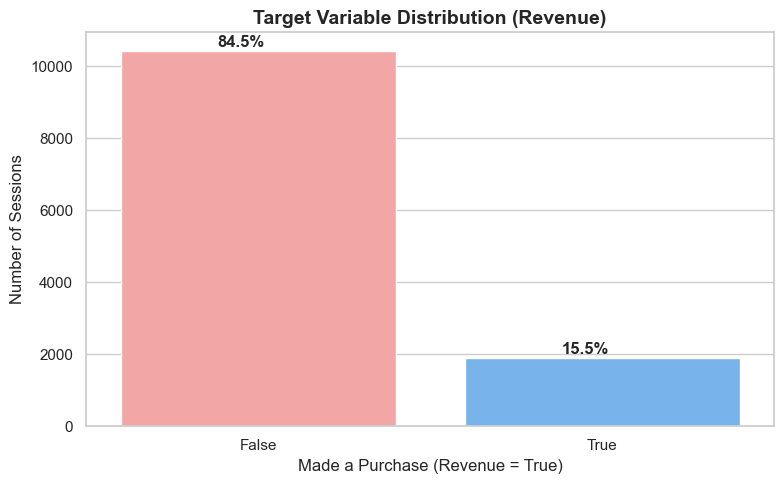

💡 OBSERVATION: The dataset is highly imbalanced (~85% False vs ~15% True).
If left untreated, models will be biased towards predicting 'False'. In the next phase, we will address this by integrating SMOTE inside the Cross-Validation pipeline to avoid data leakage.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plot style
sns.set_theme(style="whitegrid", palette="muted")

# 1. Load the Dataset
print("--- DATASET LOADING ---")
current_dir = os.path.dirname(os.path.abspath('__file__'))
file_path = os.path.join(current_dir, '../online_shoppers_intention.csv')

df = pd.read_csv(file_path).dropna().reset_index(drop=True)
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns.\n")

# 2. Target Class Imbalance Analysis
plt.figure(figsize=(8, 5))
# FIXED: Added hue='Revenue' and legend=False to avoid Seaborn deprecation warnings
ax = sns.countplot(data=df, x='Revenue', hue='Revenue', palette=['#ff9999', '#66b3ff'], legend=False)
plt.title('Target Variable Distribution (Revenue)', fontsize=14, fontweight='bold')
plt.xlabel('Made a Purchase (Revenue = True)', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

# Add percentages on top of the bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height() + 100
    ax.annotate(percentage, (x, y), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/fig_01_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 OBSERVATION: The dataset is highly imbalanced (~85% False vs ~15% True).")
print("If left untreated, models will be biased towards predicting 'False'. In the next phase, we will address this by integrating SMOTE inside the Cross-Validation pipeline to avoid data leakage.")

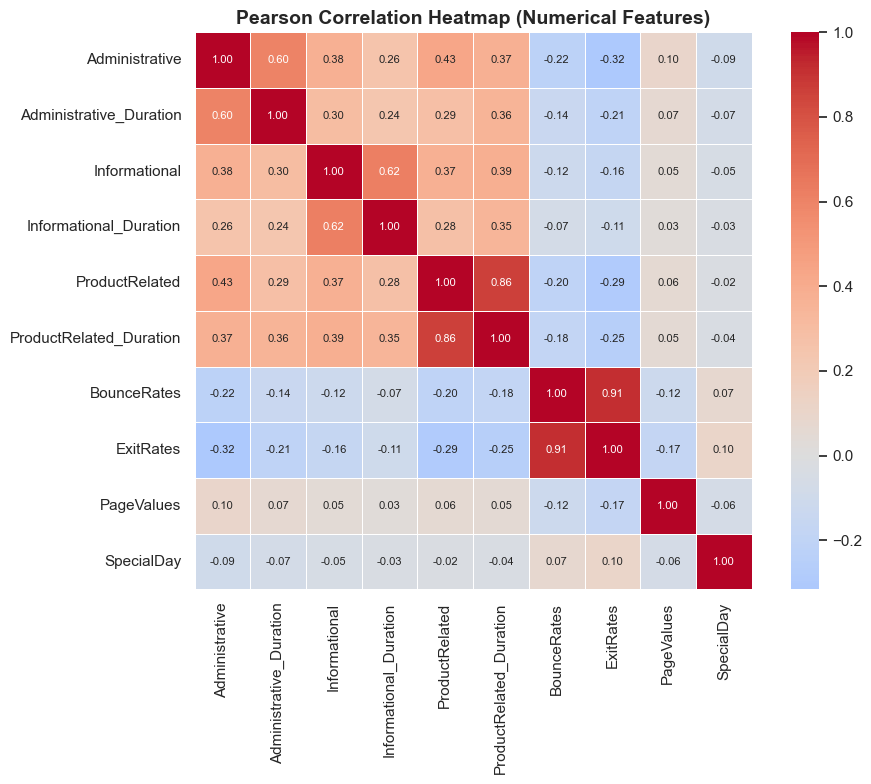

Observation: BounceRates and ExitRates are strongly correlated (r ≈ 0.91),
reflecting that sessions bouncing from a page also tend to exit from it.


In [2]:
import os
os.makedirs('../figures', exist_ok=True)

numerical_cols_heatmap = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'
]

corr = df[numerical_cols_heatmap].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Pearson Correlation Heatmap (Numerical Features)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig_02_corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observation: BounceRates and ExitRates are strongly correlated (r ≈ 0.91),")
print("reflecting that sessions bouncing from a page also tend to exit from it.")

### 2. Statistics-Driven Feature Selection
Instead of dropping features purely by intuition, we apply rigorous statistical tests to identify which variables carry the most information regarding the purchasing intention (`Revenue`).

* **Categorical Features:** We use the **Chi-Square Test ($X^2$)** to test the null hypothesis of independence between the feature and the target variable.
* **Continuous Features:** We use **Mutual Information (MI)** to measure the reduction in uncertainty (entropy) of the target given the feature.

--- CHI-SQUARE TEST RESULTS (Categorical Features) ---
OperatingSystems     | p-value: 0.0000 -> KEEP (Statistically Dependent)
Browser              | p-value: 0.0061 -> KEEP (Statistically Dependent)
Region               | p-value: 0.3214 -> DROP CANDIDATE (Independent)
TrafficType          | p-value: 0.0000 -> KEEP (Statistically Dependent)
VisitorType          | p-value: 0.0000 -> KEEP (Statistically Dependent)
Weekend              | p-value: 0.0013 -> KEEP (Statistically Dependent)
Month                | p-value: 0.0000 -> KEEP (Statistically Dependent)

--- MUTUAL INFORMATION SCORES (Numerical Features) ---


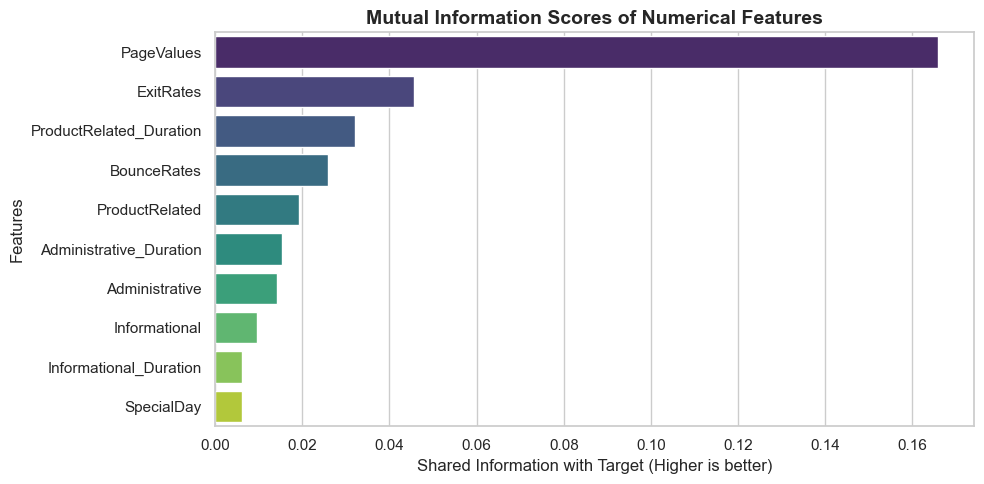

In [3]:
from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif

categorical_cols = ['OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Month']
numerical_cols = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

# --- CHI-SQUARE TEST ---
print("--- CHI-SQUARE TEST RESULTS (Categorical Features) ---")
alpha = 0.05
for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df['Revenue'])
    chi2, p_value, _, _ = chi2_contingency(contingency_table)
    outcome = "KEEP (Statistically Dependent)" if p_value < alpha else "DROP CANDIDATE (Independent)"
    print(f"{col:<20} | p-value: {p_value:.4f} -> {outcome}")

# --- MUTUAL INFORMATION ---
print("\n--- MUTUAL INFORMATION SCORES (Numerical Features) ---")
X_num = df[numerical_cols]
y = df['Revenue'].astype(int)
mi_scores = mutual_info_classif(X_num, y, random_state=42)

mi_results = pd.DataFrame({'Feature': numerical_cols, 'MI_Score': mi_scores}).sort_values(by='MI_Score', ascending=False)

plt.figure(figsize=(10, 5))
# FIXED: Added hue='Feature' and legend=False to avoid Seaborn deprecation warnings
sns.barplot(x='MI_Score', y='Feature', data=mi_results, hue='Feature', palette='viridis', legend=False)
plt.title('Mutual Information Scores of Numerical Features', fontsize=14, fontweight='bold')
plt.xlabel('Shared Information with Target (Higher is better)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/fig_03_mutual_info.png', dpi=150, bbox_inches='tight')
plt.show()

### 3. Outlier Profiling (Local Outlier Factor)
As a final exploratory step, we analyze the presence of multivariate outliers in the continuous navigation data. We use the **Local Outlier Factor (LOF)**, a density-based algorithm that identifies anomalous data points by measuring the local deviation of a given data point with respect to its neighbors. 

*Crucial Methodological Note:* In this phase, we are strictly **counting and observing** the outliers. The actual removal will occur exclusively on the training folds ($D_{train}$) during the Nested Cross-Validation, to categorically prevent test set contamination.

In [4]:
from sklearn.neighbors import LocalOutlierFactor

print("--- MULTIVARIATE OUTLIER ANALYSIS (LOF) ---")
# We only use numerical continuous variables for density-based LOF
X_outlier_check = df[numerical_cols].copy()

# Data Quality Observation
duplicate_count = X_outlier_check.duplicated().sum()
print(f"🔍 Observation: Found {duplicate_count} exactly identical rows in the numerical features.")
print("This is common in clickstream data (e.g., many users with exactly 0 pages visited).")
print("To prevent LOF calculation instability due to distance=0 between duplicates, we increase 'n_neighbors'.\n")

# Initialize LOF 
# We increase n_neighbors to 100 to ensure the neighborhood is larger than the duplicate clusters
lof = LocalOutlierFactor(n_neighbors=100, contamination=0.05)
outlier_preds = lof.fit_predict(X_outlier_check)

# Calculate totals
num_normal = (outlier_preds == 1).sum()
num_outliers = (outlier_preds == -1).sum()

print(f"Total normal sessions detected: {num_normal}")
print(f"Total potential outliers detected: {num_outliers} ({num_outliers/len(df)*100:.1f}%)")

print("\n💡 EDA CONCLUSION:")
print("We identified structural noise, overlapping behaviors, and severe class imbalance in the data.")
print("In the next stage (Notebook 2), we will build a Custom Sampler to inject this LOF cleaning step directly into the Pipeline, guaranteeing zero Data Leakage.")

--- MULTIVARIATE OUTLIER ANALYSIS (LOF) ---
🔍 Observation: Found 761 exactly identical rows in the numerical features.
This is common in clickstream data (e.g., many users with exactly 0 pages visited).
To prevent LOF calculation instability due to distance=0 between duplicates, we increase 'n_neighbors'.

Total normal sessions detected: 11713
Total potential outliers detected: 617 (5.0%)

💡 EDA CONCLUSION:
We identified structural noise, overlapping behaviors, and severe class imbalance in the data.
In the next stage (Notebook 2), we will build a Custom Sampler to inject this LOF cleaning step directly into the Pipeline, guaranteeing zero Data Leakage.


c:\Users\paris\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
